# Chapter 2: Pretrained Networks & Model Zoo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emreaslan7/ai/blob/main/notebooks/deep-learning-with-pytorch/02-pretrained-networks-and-model-zoo.ipynb)

Interactive workbook for **Chapter 2** of *Deep Learning with PyTorch (2nd Edition)*.
- **Vision Backbones:** AlexNet & Vision Transformer (ViT-B/16)
- **Preprocessing Pipeline:** Rescaling, cropping, standardization, and batch unsqueezing
- **Generative Inpainting:** Latent Diffusion (Stable Diffusion 2.0 Inpainting)
- **Unpaired Translation:** CycleGAN ResNet block
- **Multimodal Vision-Language:** Salesforce BLIP captioning
- **Complexity Analysis:** Parameter counting and GPU VRAM footprint calculation

In [2]:
# 0. Dependencies Installation, Core Imports & Device Setup
!pip install -q diffusers transformers accelerate torchvision pillow ipywidgets

import torch
import torchvision
from torchvision import models
from PIL import Image
import urllib.request

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__} | Torchvision: {torchvision.__version__} | Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.13.0+cu126 | Torchvision: 0.28.0+cu126 | Device: cuda
GPU: NVIDIA GeForce GTX 1650

---
## 1. Torchvision Model Zoo

Query available models and instantiate pretrained weights using explicit `Weights` enums.

In [3]:
# List available models in Torchvision
available_models = models.list_models()
print(f"Total available models: {len(available_models)}")
print("Sample models:", available_models[:10])

Total available models: 121
Sample models: ['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'deeplabv3_mobilenet_v3_large', 'deeplabv3_resnet101', 'deeplabv3_resnet50', 'densenet121', 'densenet161']

### 1.1 AlexNet (2012 Historical CNN Baseline)
Load AlexNet with default ImageNet-1K pretrained weights (61.1M parameters).

In [4]:
from torchvision.models import AlexNet_Weights

alexnet_weights = AlexNet_Weights.DEFAULT
alexnet = models.alexnet(weights=alexnet_weights).to(device)
print(alexnet)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

### 1.2 Vision Transformer (ViT-B/16)
Load Vision Transformer Base ($16 \times 16$ patch resolution, 12 attention blocks, 86.6M parameters).

In [5]:
from torchvision.models import ViT_B_16_Weights

vit_weights = ViT_B_16_Weights.DEFAULT
vit = models.vit_b_16(weights=vit_weights).to(device)
print(vit)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

---
## 2. Input Preprocessing Pipeline

Standardize RGB pixel values using ImageNet statistics:
$$ x'_{c,i,j} = \frac{x_{c,i,j} - \mu_c}{\sigma_c}, \quad \boldsymbol{\mu}=[0.485, 0.456, 0.406], \quad \boldsymbol{\sigma}=[0.229, 0.224, 0.225] $$

In [6]:
# Extract official preprocessing transform bound to AlexNet weights
preprocess = alexnet_weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### 2.1 Download Test Image & Apply Transformations

In [7]:
# Download canonical Golden Retriever test photo
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
with urllib.request.urlopen(url) as response:
    img = Image.open(response).convert("RGB")

# Apply preprocessing: PIL Image -> (3, 224, 224) Tensor
img_t = preprocess(img)
print(f"Preprocessed tensor shape: {img_t.shape}, Dtype: {img_t.dtype}")

Preprocessed tensor shape: torch.Size([3, 224, 224]), Dtype: torch.float32

### 2.2 Add Batch Dimension via `unsqueeze(0)`

In [8]:
# Add batch dimension: (3, 224, 224) -> (1, 3, 224, 224)
batch_t = torch.unsqueeze(img_t, 0).to(device)
print(f"Batch tensor shape: {batch_t.shape}")

Batch tensor shape: torch.Size([1, 3, 224, 224])

---
## 3. Classification Inference & Top-5 Probability Decoding

Run forward pass with `model.eval()` and `torch.inference_mode()`, then decode Softmax probabilities:
$$ P(Y=k) = \frac{\exp(z_k)}{\sum_j \exp(z_j)} $$

In [9]:
# AlexNet forward pass and Softmax probabilities
alexnet.eval()
with torch.inference_mode():
    out = alexnet(batch_t)

probabilities = torch.softmax(out, dim=1)
top5_prob, top5_catid = torch.topk(probabilities, 5)
categories = alexnet_weights.meta["categories"]

print("=== AlexNet Top-5 Predictions ===")
for i in range(top5_prob.size(1)):
    cat_id = top5_catid[0][i].item()
    score = top5_prob[0][i].item() * 100.0
    print(f"{i+1}. {categories[cat_id]:<35} ({score:.2f}%)")

=== AlexNet Top-5 Predictions ===
1. Samoyed                             (72.45%)
2. wallaby                             (13.94%)
3. Pomeranian                          (5.87%)
4. Angora                              (2.28%)
5. Arctic fox                          (1.25%)

### 3.1 Comparative Inference with ViT-B/16

In [10]:
# ViT-B/16 inference comparison
vit.eval()
vit_preprocess = vit_weights.transforms()
vit_batch_t = torch.unsqueeze(vit_preprocess(img), 0).to(device)

with torch.inference_mode():
    vit_out = vit(vit_batch_t)

vit_probs = torch.softmax(vit_out, dim=1)
vit_top5_prob, vit_top5_catid = torch.topk(vit_probs, 5)
vit_categories = vit_weights.meta["categories"]

print("=== ViT-B/16 Top-5 Predictions ===")
for i in range(vit_top5_prob.size(1)):
    cat_id = vit_top5_catid[0][i].item()
    score = vit_top5_prob[0][i].item() * 100.0
    print(f"{i+1}. {vit_categories[cat_id]:<35} ({score:.2f}%)")

=== ViT-B/16 Top-5 Predictions ===
1. Samoyed                             (79.97%)
2. Pomeranian                          (3.70%)
3. keeshond                            (1.72%)
4. Japanese spaniel                    (0.57%)
5. Eskimo dog                          (0.51%)

---
## 4. Generative Vision: Latent Diffusion Inpainting (Stable Diffusion 2.0)

Selectively repaint masked regions conditioned on text prompts using `diffusers`.

In [16]:
from diffusers import StableDiffusionInpaintPipeline
import torch
from PIL import Image
import urllib.request

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

# 1. Modeli yükle
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "sd2-community/stable-diffusion-2-inpainting",
    torch_dtype=dtype
).to(device)



D:\code\ai\.venv\Lib\site-packages\diffusers\utils\deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

### 4.1 Load CompVis Benchmark Image & Binary Mask

In [17]:
# 2. Görseli ve maskeyi al
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

with urllib.request.urlopen(img_url) as r:
    init_image = Image.open(r).convert("RGB").resize((512, 512))
    
with urllib.request.urlopen(mask_url) as r:
    mask_image = Image.open(r).convert("L").resize((512, 512))
    
prompt = "a sitting cat on a park bench, 8k resolution, photorealistic"

### 4.2 Execute Inpainting Denoising Sampling

In [18]:
with torch.inference_mode():
    output = pipe(
        prompt=prompt,
        image=init_image,
        mask_image=mask_image,
        num_inference_steps=25,
        guidance_scale=7.5,
        generator=torch.Generator(device=device).manual_seed(42) if device == "cuda" else None
    )
    
inpainted_image = output.images[0]
inpainted_image.save("inpainted_bench_cat.png")
print("Inpainting done! 'inpainted_bench_cat.png' saved!")


  0%|          | 0/25 [00:00<?, ?it/s]

Inpainting done! 'inpainted_bench_cat.png' saved!

Mask Image:

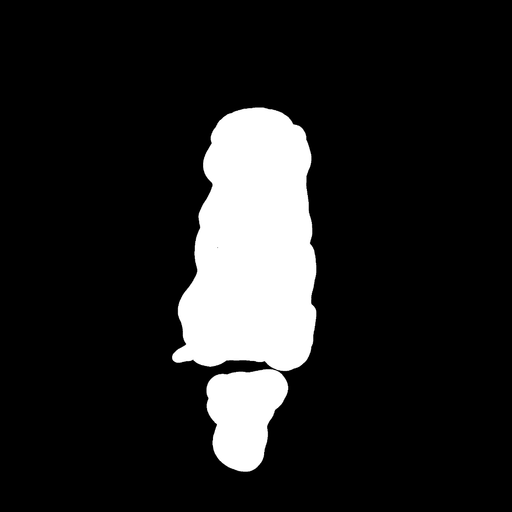

Original Image:

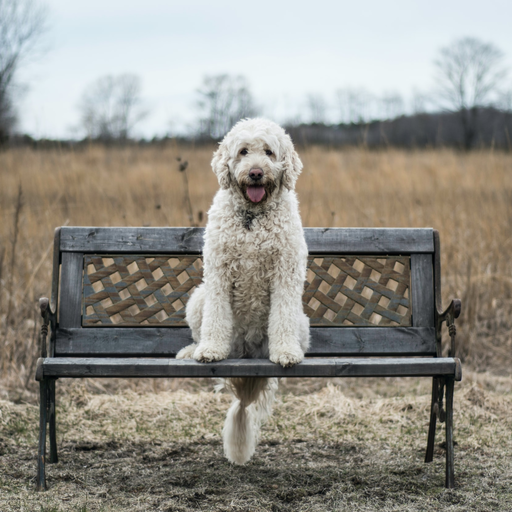

Inpainted Image:

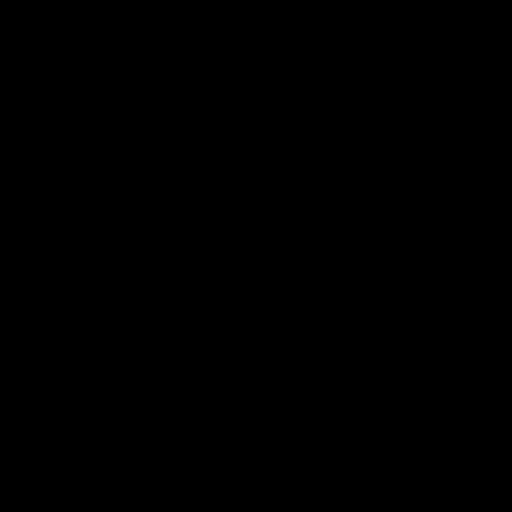

In [19]:
from IPython.display import display

print("Mask Image:")
display(mask_image)

print("Original Image:")
display(init_image)

print("Inpainted Image:")
display(inpainted_image)

---
## 5. Unpaired Image Translation: CycleGAN ResNet Block

Cycle consistency residual block with reflection padding and instance normalization:
$$ F(G(x)) \approx x, \quad G(F(y)) \approx y $$

In [20]:
import torch.nn as nn

class ResNetBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3, padding=0, bias=False),
            nn.InstanceNorm2d(dim),
            nn.ReLU(True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3, padding=0, bias=False),
            nn.InstanceNorm2d(dim)
        )

    def forward(self, x):
        return x + self.conv_block(x)

# Test forward pass with dummy feature tensor
block = ResNetBlock(256).to(device)
dummy = torch.randn(1, 256, 64, 64).to(device)
out_block = block(dummy)
print(f"Input: {dummy.shape} -> Output: {out_block.shape}")

Input: torch.Size([1, 256, 64, 64]) -> Output: torch.Size([1, 256, 64, 64])

---
## 6. Vision-Language Multimodal Inference: BLIP

Autoregressive image captioning via ViT visual encoder and cross-attention text decoder.

In [21]:
from transformers import BlipProcessor, BlipForConditionalGeneration

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)
blip_model.eval()
print("BLIP Processor & Model loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

D:\code\ai\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\emrea\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

BLIP Processor & Model loaded successfully.

### 6.1 Unconditional & Conditional Captioning

In [22]:
# 1. Unconditional Captioning
inputs_unc = processor(images=img, return_tensors="pt").to(device)
with torch.inference_mode():
    out_unc = blip_model.generate(**inputs_unc, max_new_tokens=30)
    caption_unc = processor.decode(out_unc[0], skip_special_tokens=True)
print(f"Unconditional: '{caption_unc}'")

# 2. Conditional Prompt-Guided Captioning
prompt_text = "a photography of"
inputs_cond = processor(images=img, text=prompt_text, return_tensors="pt").to(device)
with torch.inference_mode():
    out_cond = blip_model.generate(**inputs_cond, max_new_tokens=30)
    caption_cond = processor.decode(out_cond[0], skip_special_tokens=True)
print(f"Conditional:   '{caption_cond}'")

Unconditional: 'a white dog sitting in the grass'Conditional:   'a photography of a white dog sitting in the grass'

---
## 7. Model Parameters & GPU VRAM Footprint Analysis

$$ \text{VRAM} = N_{\text{params}} \times B_{\text{dtype}} $$

In [23]:
def calculate_vram_footprint(name, model_obj):
    num_params = sum(p.numel() for p in model_obj.parameters())
    trainable_params = sum(p.numel() for p in model_obj.parameters() if p.requires_grad)
    fp32_mb = (num_params * 4) / (1024 ** 2)
    fp16_mb = (num_params * 2) / (1024 ** 2)
    
    print(f"=== {name} ===")
    print(f"Total Params:     {num_params / 1e6:.2f} M ({num_params:,})")
    print(f"Trainable Params: {trainable_params / 1e6:.2f} M")
    print(f"Static VRAM FP32: {fp32_mb:.2f} MB | FP16: {fp16_mb:.2f} MB\n")

calculate_vram_footprint("AlexNet", alexnet)
calculate_vram_footprint("ViT-B/16", vit)
calculate_vram_footprint("BLIP-Base", blip_model)

=== AlexNet ===
Total Params:     61.10 M (61,100,840)
Trainable Params: 61.10 M
Static VRAM FP32: 233.08 MB | FP16: 116.54 MB

=== ViT-B/16 ===
Total Params:     86.57 M (86,567,656)
Trainable Params: 86.57 M
Static VRAM FP32: 330.23 MB | FP16: 165.11 MB

=== BLIP-Base ===
Total Params:     223.97 M (223,971,644)
Trainable Params: 223.97 M
Static VRAM FP32: 854.38 MB | FP16: 427.19 MB
